<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 50%, #0a0a1a 100%); padding: 40px 32px 32px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-bottom: 8px;">

<div style="display: flex; align-items: flex-start; gap: 24px;">
<div style="flex: 1;">

<p style="color: #7eb8e0; font-family: 'Courier New', monospace; font-size: 20px; letter-spacing: 3px; margin: 0 0 10px 0; text-transform: uppercase;">Cosmic Explosion Exploration - LIGO Gravitational Wave Analysis Pipeline</p>

<h1 style="color: #e8f4fd; font-size: 2.2em; margin: 0 0 6px 0; font-weight: 300; letter-spacing: 1px;">Notebook 04 — Feature Extraction</h1>

<p style="color: #a0c4de; font-size: 1.05em; margin: 0 0 20px 0; font-style: italic;">Transforming processed strain into a structured, physically interpretable feature matrix</p>

<div style="display: flex; gap: 24px; flex-wrap: wrap;">
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Input</p>
    <p style="color: #e8f4fd; font-size: 0.95em; font-weight: 600; margin: 0; font-family: 'Courier New', monospace;">GW150914_processed.hdf5</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">from notebook 02</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Outputs</p>
    <p style="color: #e8f4fd; font-size: 0.95em; font-weight: 600; margin: 0; font-family: 'Courier New', monospace;">*_features.json · *_features.csv</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">ready for notebook 05</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Pipeline stage</p>
    <p style="color: #e8f4fd; font-size: 1.2em; font-weight: 600; margin: 0;">04 of 06</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">time · frequency · chirp · Q-transform</p>
  </div>
</div>

</div>
</div>

<hr style="border: none; border-top: 1px solid rgba(126,184,224,0.2); margin: 24px 0 16px 0;">

<p style="color: #7eb8e0; font-size: 12px; font-family: 'Courier New', monospace; margin: 0;">
  <span style="opacity:0.6;">Pipeline:</span> &nbsp;
</p>

</div>

In [1]:
from pipeline_banner import pipeline_banner
pipeline_banner(4)   # ← change the number per notebook

## What is feature extraction and why do we use it?
Feature extraction is the process of transforming raw data into a smaller set of meaningful numbers that capture the essential character of what you are trying to analyse or predict.
In this pipeline, the raw data is a time-series set of 131,072 strain measurement samples. Machine learning models and statistical classifiers cannot directly consume such a large set of raw time-series samples and simply interpret. They need a **compact, meaningful representation** set of numbers — features that capture the essential character of the signal.

Here feature extraction condenses that raw data into 18 numbers per detector — things like peak frequency, chirp mass, kurtosis, and Q-transform energy concentration. Each number describes something specific and interpretable about the signal.
It sits on a spectrum from raw data at one end to a fully compressed summary at the other. Feature extraction lives in the middle — it is a deliberate, informed reduction.

Feature extraction is the bridge between the physics of the signal and the mathematics of the model. Well-chosen features also have **physical interpretability** — each one corresponds to something real about the source: the masses of the black holes, how loud the signal was, how quickly it swept through frequency. A model that learns from physically meaningful features is easier to validate and trust.

### What is its purpose?
 - **Dimensionality reduction:** Most models do not learn well from large sets of raw numbers (e.g. like our 131,072 samples). That many inputs create what is called the curse of dimensionality and such a model needs exponentially more training data to learn meaningful patterns from it as the number of inputs grows. Compressing the data to 18x features makes the learning problem more manageable.
 - **Noise suppression:** Raw data contains irrelevant variation, and for LIGO this means most of the time. Things like detector noise, measurement artefacts, the quiet regions far from the merger. A well-chosen feature like "peak Q-transform energy" captures the signal without carrying all that noise into the model.
 - **Physical interpretability:** Your chirp mass estimate, your spectral centroid, your kurtosis — each of these things has a physical meaning related to the event being observed. A model trained on features like these is easier to validate and to trust. You can reason about why it reached such a conclusion. A black box model trained on raw samples is harder to interrogate.
 - **Generalisation:** Features that capture physical structure tend to transfer better across events. Chirp mass works for GW150914, GW170817, and GW190521 — the underlying physics is the same even if the raw waveforms look quite different.


| Feature group | Features extracted | Physical meaning |
|--------------|-------------------|------------------|
| Time-domain | Peak amplitude, RMS, SNR, kurtosis, skewness | Signal amplitude, power, statistical shape |
| Frequency-domain | Peak frequency, spectral centroid, bandwidth, spectral entropy | Where the power lives spectrally |
| Chirp physics | Inspiral frequency sweep rate, chirp mass estimate | The masses of the merging objects |
| Q-transform | Peak energy, time of peak, frequency of peak, energy concentration | Time-frequency signature strength |



*All hard-coded parameters used in this workbook (physical constants, time windows, plot limits) are sourced from `config.py`. No parameter values are embedded in this notebook to remove the possibility of inconsistency across notebooks.*

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 0 — Environment Setup</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Imports, pipeline wiring, and matplotlib theme. Physical constants come from <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">PHYSICS</code> in config.py; all paths from <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">PATHS</code>.</p>
</div>

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import sys
import json

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, hilbert, welch
from scipy.stats import kurtosis, skew
from scipy.ndimage import uniform_filter1d

# ── LIGO-specific ─────────────────────────────────────────────────────────────
from gwpy.timeseries import TimeSeries

# ── Pipeline modules ──────────────────────────────────────────────────────────
sys.path.insert(0, ".")
from config import PATHS, EVENT, SIGNAL, VIZ, PHYSICS, PHASE_MARKERS
from utils import (
    load_processed_hdf5,
    time_relative_to_merger,
    crop_to_window,
    estimate_snr,
    check_pipeline_files,
)

%matplotlib inline
PATHS.make_dirs()   # Creates data/features/ alongside other dirs
print("✓ Imports complete.")

✓ Imports complete.


In [3]:
# ── Deep-space matplotlib theme (mirrors notebooks 01–03) ─────────────────────
SPACE_BG     = "#0d1117"
SPACE_AXES   = "#131c27"
SPACE_GRID   = "#1e2d3e"
SPACE_TEXT   = "#c9d9e8"
SPACE_BORDER = "#2a4a6e"

# Wes Anderson detector palette
WA_COLOURS = {
    "H1":        "#E07B54",   # Warm coral-orange
    "L1":        "#5AAFA0",   # Dusty teal-green
    "V1":        "#D4A84B",   # Warm golden sand
    "merger":    "#F2C46D",   # Butter-yellow
    "envelope":  "#B8D4E8",   # Pale blue for amplitude envelope
    "inst_freq": "#C4A8DA",   # Soft lilac for instantaneous frequency
}

plt.rcParams.update({
    "figure.facecolor":  SPACE_BG,
    "axes.facecolor":    SPACE_AXES,
    "savefig.facecolor": SPACE_BG,
    "text.color":        SPACE_TEXT,
    "axes.labelcolor":   SPACE_TEXT,
    "xtick.color":       SPACE_TEXT,
    "ytick.color":       SPACE_TEXT,
    "axes.edgecolor":    SPACE_BORDER,
    "grid.color":        SPACE_GRID,
    "grid.linewidth":    0.6,
    "axes.grid":         True,
    "axes.grid.which":   "both",
    "axes.titlesize":    12,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "lines.linewidth":   0.9,
    "axes.linewidth":    0.8,
    "figure.constrained_layout.use": True,
})

print("✓ Deep-space theme applied.")

✓ Deep-space theme applied.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 1 — Pipeline Pre-check &amp; Data Load</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Verify upstream notebooks have run, load the processed strain, and echo configuration. All parameters below come from <code style="background: rgba(78,158,202,0.15); padding: 2px 6px; border-radius: 3px;">config.py</code>.</p>
</div>

In [4]:
check_pipeline_files(EVENT.NAME)

processed, prep_params = load_processed_hdf5(EVENT.NAME)

SR     = float(processed["H1"].sample_rate.value)   # Hz — used throughout
phases = PHASE_MARKERS.get(EVENT.NAME, {})

print(f"\nSample rate           : {SR:.0f} Hz")
print(f"Noise window          : {SIGNAL.NOISE_WINDOW}")
print(f"Signal window         : {SIGNAL.SIGNAL_WINDOW}")
print(f"Inspiral fit window   : {phases.get('inspiral_window', 'n/a')}")
print(f"Physical constants    : G = {PHYSICS.G}, c = {PHYSICS.C}, M☉ = {PHYSICS.M_SUN_KG} kg")
print(f"Features output dir   : {PATHS.FEATURES_DIR.resolve()}")

Pipeline file check — GW150914:
  [✓] Raw HDF5 (notebook 01): data\raw\GW150914_raw.hdf5
  [✓] Processed HDF5 (notebook 02): data\processed\GW150914_processed.hdf5

All upstream files present. Ready to proceed.
Loaded processed data (GW150914): H1 [131072 samples], L1 [131072 samples]
Preprocessing applied: ['whiten' 'bandpass' 'notch']

Sample rate           : 4096 Hz
Noise window          : (-15.0, -5.0)
Signal window         : (-0.5, 0.5)
Inspiral fit window   : (-0.2, -0.05)
Physical constants    : G = 6.674e-11, c = 300000000.0, M☉ = 1.989e+30 kg
Features output dir   : C:\Users\paddy\Jupyter_Notebooks\LIGO Exploration\data\features


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 2 — Time-Domain Features</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Features computed directly on the strain time-series — no frequency transformation. They describe the amplitude, power, and statistical shape of the signal.</p>
</div>

### Feature definitions

**Peak amplitude** — the maximum absolute strain value in the signal window. For a gravitational wave chirp this occurs at or very close to the merger, corresponding to the final moments of coalescence.

**RMS (Root Mean Square)** — $\sqrt{\langle h^2 \rangle}$, the square root of mean squared strain. RMS is the natural measure of average power in a signal, and strain is fundamentally an oscillating quantity as it swings positive and negative around zero as the gravitational wave passes.
If we simply took the arithmetic mean of the strain values, positive and negative excursions would cancel each other.
For gravitational waves, the power radiated scales with the square of the strain amplitude, so RMS strain is a physically meaningful quantity.
We also use the ratio of two RMS values to estimate the SNR value in pipeline:
$$\text{SNR} \approx \frac{\text{RMS}_{\text{signal window}}}{\text{RMS}_{\text{noise window}}}$$
We get this by comparing the power in a quiet region (dominated by detector noise) vs. the power in the merger window (noise + signal). If the signal is real, then the resultant ratio should be noticeably >1.

**Kurtosis** — measures the 'tailedness' of the amplitude distribution. Gaussian noise has Fisher kurtosis = 0. A real transient signal buried in noise produces heavier tails → kurtosis > 0. This is one of the earliest tests LIGO operators apply when flagging candidate events.

<img src="data/visualisations/kurtosis_dark_theme.png" 
     alt="Kurtosis distribution comparison" 
     width="800"
     style="display: block; margin: auto;"/>

Pure LIGO detector noise, which is what is measured most of the time when nothing interesting is happening, is approximately Gaussian with kurtosis ≈ 0. 
A real transient signal, like a gravitational wave chirp, injects occasional large amplitude excursions into the strain data. These are not distributed symmetrically around zero — they are rare, brief, and large. This pushes the distribution toward the leptokurtic shape (orange in the example chart): a sharp central peak from all the ordinary noise, plus heavier tails from the signal.


**Skewness** — measures the asymmetry of a distribution — whether the tail on one side is longer or heavier than the other. A perfectly symmetric distribution or pure Gaussian noise has skewness ≈ 0. Skewness is not the strongest feature in the time-domain group but it still has use.
Skewness is a cheap glitch discriminator. Instrumental glitches — spurious noise transients from things like scattered light, seismic events, or electronics — often produce strongly skewed distributions because they tend to be one-sided spikes rather than oscillatory signals. A real gravitational wave chirp is oscillatory and more symmetric than a glitch, so extreme skewness (large positive or negative) is a flag that something non-astrophysical may be present in the signal.  

Skewness is sensitive to preprocessing quality. If the whitening or bandpass filtering has left an artefact — for example a sharp edge effect at the start or end of the segment — skewness will catch it because those artefacts tend to be one-sided.  
Different collision types have different skewness properties, e.g. Binary black hole (BBH) like this collision has skewness close to zero, perhaps slightly negative due to the rapid post-merger amplitude drop. A Neutron star–black hole (NSBH) merger like GW200105 produces a more asymmetric distribution than a clean BBH ringdown.  

In practice, skewness is not a primary detection statistic in LIGO's production pipelines — matched filtering and coherent network analysis are far more powerful. But as a feature in a machine learning classifier trained to distinguish signal types or rank candidate events, skewness contributes marginal discriminating power that is essentially free to compute. In a feature matrix with 18 columns, a feature that adds even a small amount of independent information is worth keeping.  

In [5]:
time_features = {}

print(f"{'Feature':<30} {'H1':>14} {'L1':>14}")
print("-" * 60)

for det, ts in processed.items():
    t = time_relative_to_merger(ts)
    v = ts.value

    noise_mask  = (t >= SIGNAL.NOISE_WINDOW[0])  & (t <= SIGNAL.NOISE_WINDOW[1])
    signal_mask = (t >= SIGNAL.SIGNAL_WINDOW[0]) & (t <= SIGNAL.SIGNAL_WINDOW[1])

    v_noise  = v[noise_mask]
    v_signal = v[signal_mask]

    peak_amp   = float(np.max(np.abs(v_signal)))
    noise_rms  = float(np.sqrt(np.mean(v_noise  ** 2)))
    signal_rms = float(np.sqrt(np.mean(v_signal ** 2)))
    snr        = float(signal_rms / noise_rms)

    # Kurtosis and skewness on the full segment — we want the distributional
    # shape of the whole strain, which a real signal distorts relative to pure noise
    kurt = float(kurtosis(v, fisher=True))  # Fisher: Gaussian = 0
    skw  = float(skew(v))

    time_features[det] = {
        "peak_amplitude":  peak_amp,
        "noise_rms":       noise_rms,
        "signal_rms":      signal_rms,
        "simple_snr":      snr,
        "kurtosis":        kurt,
        "skewness":        skw,
    }

for fname in time_features["H1"]:
    print(f"{fname:<30} {time_features['H1'][fname]:>14.4f} {time_features['L1'][fname]:>14.4f}")

print()
print("Note: kurtosis uses Fisher definition (Gaussian = 0, not 3).")
print("Values > 0 suggest heavier tails than Gaussian — consistent with a real transient.")

Feature                                    H1             L1
------------------------------------------------------------
peak_amplitude                         2.5678         2.3439
noise_rms                              0.3389         0.3447
signal_rms                             0.4239         0.3840
simple_snr                             1.2509         1.1140
kurtosis                               0.4213         0.1279
skewness                               0.0139         0.0125

Note: kurtosis uses Fisher definition (Gaussian = 0, not 3).
Values > 0 suggest heavier tails than Gaussian — consistent with a real transient.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 3 — Instantaneous Frequency via the Hilbert Transform</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">The chirp sweeps upward in frequency — we need to track <em>how</em> the frequency evolves over time. The Hilbert transform constructs the analytic signal, from which the instantaneous phase and frequency can be extracted.</p>
</div>

### The analytic signal and instantaneous frequency
The raw strain h(t) is just a list of numbers that go up and down over time — a single real-valued waveform. The problem is that from a pure up-down oscillation alone, it is hard to extract two things you want to know simultaneously: how loud the signal is at any moment, and what frequency it is at any moment.

The **Hilbert transform** constructs the **analytic signal** $z(t)$ from the real strain $h(t)$:

$$z(t) = h(t) + i \, \mathcal{H}[h(t)] = A(t) \, e^{i\phi(t)}$$

where $A(t)$ is the **amplitude envelope** and $\phi(t)$ is the **instantaneous phase**. From those two numbers at every point in time you can extract:

**A(t) — the amplitude envelope:** This is the "outline" of the waveform — how tall the oscillations are at each moment. If you imagine the waveform as a rapidly vibrating string, the envelope is the smooth curved boundary that contains it. For GW150914 you expect this to rise gradually during the inspiral and peak sharply at merger.  
**φ(t) — the instantaneous phase:** This tracks exactly where in its cycle the oscillation is at each moment — like reading the angle of the clock hand continuously through time.

The **instantaneous frequency** follows directly:
If you know how the phase is changing, you know the frequency — because frequency is just how quickly the phase advances. A signal at 100 Hz completes 100 full cycles per second, meaning its phase advances 100 × 360 degrees per second. So the instantaneous frequency is simply the rate of change of the phase:

$$f_\text{inst}(t) = \frac{1}{2\pi} \frac{d\phi}{dt}$$

For GW150914, this should reveal the frequency starting around 35–50 Hz well before the merger and sweeping to ~150 Hz at coalescence. This gives the observational signature of the inspiral acceleration of this collision event. The instantaneous frequency estimate is noisy far from the signal window, so we clip it to the bandpass range and display only the late inspiral region.

The 0.4 seconds window that we are exploring in the LIGO data is real — that is genuinely how long the final inspiral took. There is no translation or time-stretching effect that distorts the observed duration. A gravitational wave travels at the speed of light and arrives at Earth with its timing essentially intact (there are tiny cosmological corrections due to the expansion of the universe, but they are negligible for a 'near' source at 1.3 billion light-years).  

This small timescale has vast contrast when compared to how long ago this whole process was initially triggered when these two black holes first became gravitationally bound as a binary system early in the universe's history (with best estimates of starting to collision in the order of several billion to over ten billion years). A dramatic end to a long lived cosmic dance.

A rought overview of the timeline:

| Phase | Duration |
|--------------|-------------------|
| Progenitor stars live and die, black holes form | ~millions of years |
| Binary system slowly loses energy to gravitational waves | ~billions of years |
| Separation closes to a few hundred km, inspiral accelerates | ~thousands of years |
| Final few orbits, frequency enters LIGO band (~35 Hz) | ~0.4 seconds |
| Merger and ringdown | ~0.1 seconds |

So the signal that we are looking at here is from merger happened 1.3 billion years ago — before complex multicellular life existed on Earth. The gravitational wave ripple expanded outward from that point at the speed of light in every direction, like a ripple on a pond, growing fainter as it spread. By the time it reached Earth on 14 September 2015, the strain amplitude had fallen to ~10⁻²¹ — this faintness is purely the result of distance, not of time distortion.


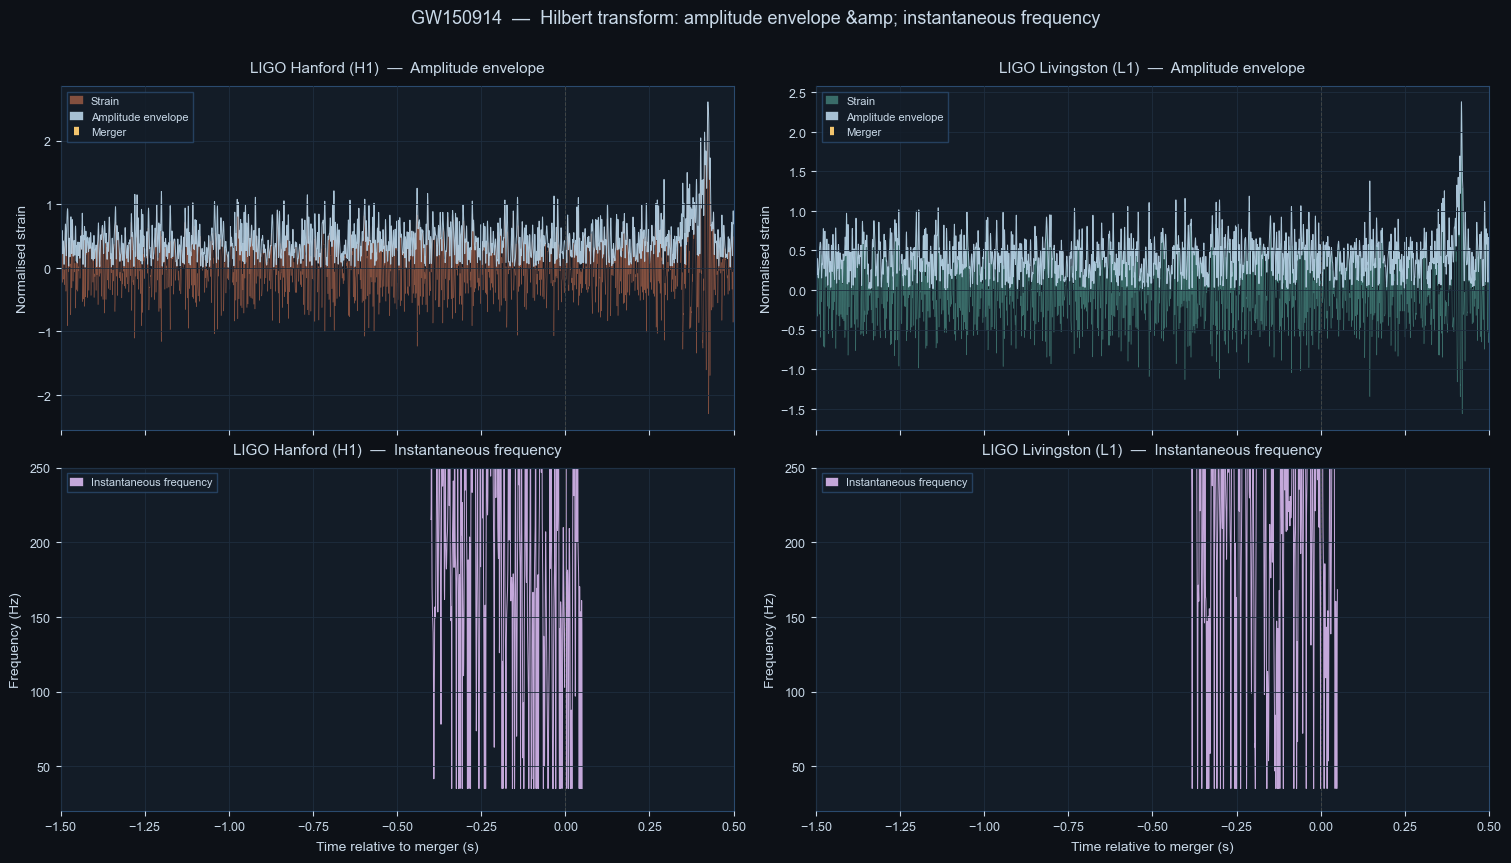

Figure saved → data\visualisations\GW150914_hilbert_envelope_freq.png


In [6]:
instantaneous_freq = {}
amplitude_envelope = {}

# Signal window for plotting the instantaneous frequency track.
# Slightly wider than SIGNAL.SIGNAL_WINDOW to catch the full inspiral sweep.
INST_FREQ_PLOT_WINDOW = (-0.4, 0.05)

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

for col_idx, det in enumerate(EVENT.DETECTORS):
    colour  = WA_COLOURS.get(det, "#7eb8e0")
    label   = EVENT.DETECTOR_LABELS.get(det, det)
    ts      = processed[det]
    t       = time_relative_to_merger(ts)
    v       = ts.value

    # Construct analytic signal via Hilbert transform
    analytic  = hilbert(v)
    envelope  = np.abs(analytic)                     # A(t)
    phase     = np.unwrap(np.angle(analytic))        # φ(t) — unwrapped to remove 2π jumps
    inst_freq = np.gradient(phase, 1.0 / SR) / (2 * np.pi)

    # Clip to the bandpass range — noise outside the band produces unphysical spikes
    inst_freq_clipped = np.clip(inst_freq,
                                SIGNAL.BANDPASS_LOW_HZ,
                                SIGNAL.BANDPASS_HIGH_HZ)

    instantaneous_freq[det] = inst_freq_clipped
    amplitude_envelope[det] = envelope

    # ── Amplitude envelope (top row) ──────────────────────────────────────────
    ax_env = axes[0, col_idx]
    ax_env.plot(t, v,        color=colour,                 lw=0.35, alpha=0.55, label="Strain")
    ax_env.plot(t, envelope, color=WA_COLOURS["envelope"], lw=0.7,  alpha=0.90, label="Amplitude envelope")
    ax_env.axvline(0, color=WA_COLOURS["merger"], lw=0.7, ls="--", label="Merger")
    ax_env.set_title(f"{label}  —  Amplitude envelope", fontsize=11, pad=10)
    ax_env.set_ylabel(VIZ.YLABEL_NORM_STRAIN)
    ax_env.set_xlim(*VIZ.HILBERT_XLIM)   # from config.py: (-1.5, 0.5)
    ax_env.legend(fontsize=8)

    # ── Instantaneous frequency (bottom row) ───────────────────────────────────
    ax_freq = axes[1, col_idx]
    sig_mask = (t >= INST_FREQ_PLOT_WINDOW[0]) & (t <= INST_FREQ_PLOT_WINDOW[1])
    ax_freq.plot(t[sig_mask], inst_freq_clipped[sig_mask],
                 color=WA_COLOURS["inst_freq"], lw=0.7, label="Instantaneous frequency")
    ax_freq.axvline(0, color=WA_COLOURS["merger"], lw=0.7, ls="--")
    ax_freq.set_title(f"{label}  —  Instantaneous frequency", fontsize=11, pad=10)
    ax_freq.set_ylabel(VIZ.XLABEL_FREQ)
    ax_freq.set_xlabel(VIZ.XLABEL_TIME)
    ax_freq.set_ylim(*VIZ.INST_FREQ_YLIM)   # from config.py: (20, 250)
    ax_freq.legend(fontsize=8)

fig.suptitle(
    f"{EVENT.NAME}  —  Hilbert transform: amplitude envelope &amp; instantaneous frequency",
    fontsize=13, y=1.06
)
fig.savefig(PATHS.viz_output(EVENT.NAME, "hilbert_envelope_freq"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'hilbert_envelope_freq')}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 4 — Frequency-Domain Features</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Characterise the spectral shape of the signal in the merger window — where the power is concentrated, how wide the band is, and how organised the spectrum looks relative to noise.</p>
</div>

### Feature definitions

**Peak frequency** — the frequency with maximum power in the bandpass. For GW150914 this corresponds roughly to the gravitational wave frequency at merger (~150 Hz).

**Spectral centroid** — the power-weighted average frequency, the 'centre of mass' of the spectrum:
$$f_\text{centroid} = \frac{\sum_i f_i \cdot P(f_i)}{\sum_i P(f_i)}$$
This is of interest because it tells us where the signal is predominantly sitting in frequency domain. It is laos a discriminator between different cosmic collision event types. Collisions of larger objects (like the massive binary black holes (BBH) that we are looking at here) have lower frequency centroids. Lighter objects (like a binary neutron star (BNS)) merge at higher frequencies - potentially above 1kHz. An instrumentation glitch can have a very different centroid and can be ruled out because of this.

**Spectral bandwidth** — the power-weighted standard deviation around the centroid. A narrow bandwidth indicates a tone-like signal; a wide bandwidth indicates a broadband signal or a rapidly sweeping chirp.
Again this measure can distinguish between light and heavy BBH systems, BBH vs. BNS or just signal vs. glitches.

**Spectral entropy** — how flat vs peaked the spectrum is. A perfectly flat spectrum (white noise) has maximum entropy. A sharp spectral peak has low entropy:
$$H = -\sum_i p_i \log_2 p_i \quad \text{where} \quad p_i = \frac{P(f_i)}{\sum_j P(f_j)}$$
Spectral entropy is sensitive to how organised the signal's frequency content is, which turns out to be physically meaningful across the three merger phases and across different event types.
Pure detector noise has high entropy. The noise floor spreads power relatively evenly across the band — no particular frequency dominates strongly. This is the baseline you are comparing against.
During the inspiral the signal introduces a concentration of power at the current chirp frequency, pulling entropy downward slightly. The spectrum is no longer flat — there is a preferred frequency, even if it is slowly moving.
At merger something interesting happens. The signal is at its loudest and sweeping fastest, which means power is spread across a wider range of frequencies simultaneously — pushing entropy back up slightly compared to the slow inspiral. But the power is still far more organised than pure noise, so entropy remains below the noise baseline.
During ringdown the black hole rings at its characteristic frequency — a relatively pure exponentially decaying tone. This is the most organised phase spectrally, the closest to a single frequency, so entropy is at its lowest.

All features are computed on the **signal window** to ensure we are measuring the signal, not the noise background.

In [7]:
freq_features = {}

print(f"{'Feature':<32} {'H1':>14} {'L1':>14}")
print("-" * 62)

for det, ts in processed.items():
    ts_sig = crop_to_window(ts, SIGNAL.SIGNAL_WINDOW)
    v_sig  = ts_sig.value

    # Welch PSD on the short signal window
    nperseg = min(256, len(v_sig) // 4)
    freqs, psd = welch(v_sig, fs=SR, nperseg=nperseg, scaling="density")

    # Restrict to the bandpass region
    band_mask = (freqs >= SIGNAL.BANDPASS_LOW_HZ) & (freqs <= SIGNAL.BANDPASS_HIGH_HZ)
    f_band    = freqs[band_mask]
    p_band    = psd[band_mask]

    total_power  = np.sum(p_band)

    peak_freq    = float(f_band[np.argmax(p_band)])
    centroid     = float(np.sum(f_band * p_band) / total_power)
    bandwidth    = float(np.sqrt(np.sum(p_band * (f_band - centroid) ** 2) / total_power))

    p_norm       = p_band / total_power + 1e-30
    spec_entropy = float(-np.sum(p_norm * np.log2(p_norm)))

    freq_features[det] = {
        "peak_frequency_hz":     peak_freq,
        "spectral_centroid_hz":  centroid,
        "spectral_bandwidth_hz": bandwidth,
        "spectral_entropy_bits": spec_entropy,
    }

for fname in freq_features["H1"]:
    print(f"{fname:<32} {freq_features['H1'][fname]:>14.4f} {freq_features['L1'][fname]:>14.4f}")

Feature                                      H1             L1
--------------------------------------------------------------
peak_frequency_hz                       48.0000       336.0000
spectral_centroid_hz                   178.8924       199.6347
spectral_bandwidth_hz                   96.4403        93.6164
spectral_entropy_bits                    4.1030         4.0938


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 5 — Chirp Mass Estimation</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">The chirp mass is the single most directly measurable property of a compact binary merger. It is encoded in the rate at which the gravitational wave frequency increases during the inspiral. Physical constants come from <code style="background: rgba(78,158,202,0.15); padding: 2px 6px; border-radius: 3px;">PHYSICS</code> in config.py; the inspiral fit window from <code style="background: rgba(78,158,202,0.15); padding: 2px 6px; border-radius: 3px;">PHASE_MARKERS</code>.</p>
</div>

### What is chirp mass and why can we measure it from the signal alone?
Because **chirp mass** $\mathcal{M}$  is precisely the combination of the two component masses that controls the leading-order gravitational wave frequency evolution — this makes this relationship explicit and analytically tractable. 

The **chirp mass** $\mathcal{M}$ is a combination of the two component masses that controls the evolution of the gravitational wave frequency:

$$\mathcal{M} = \frac{(m_1 m_2)^{3/5}}{(m_1 + m_2)^{1/5}}$$

For GW150914, with $m_1 \approx 36\,M_\odot$ and $m_2 \approx 29\,M_\odot$, the published chirp mass is $\mathcal{M} \approx 28.3\,M_\odot$.

The key relationship is between the gravitational wave frequency $f$, its rate 
of change $\dot{f}$ (the observable frequency derivative), and the chirp mass $\mathcal{M}$:

$$\dot{f} = \frac{96}{5} \pi^{8/3} \left(\frac{G\mathcal{M}}{c^3}\right)^{5/3} f^{11/3}$$

This tells you that if you can measure how quickly the frequency is sweeping —
which you can, directly from the signal using the Hilbert instantaneous 
frequency — you can solve for $\mathcal{M}$. Everything else in the equation 
is either a known physical constant or the measured frequency itself.

So this becomes:

$$\mathcal{M} = \frac{c^3}{G} \left( \frac{5}{96} \pi^{-8/3} f^{-11/3} \dot{f} \right)^{3/5}$$

This relation is valid only during the **inspiral regime** — when the black holes are still well-separated and the orbit is slowly decaying. Very close to merger, strong-field general-relativistic effects dominate and at this stage the post-Newtonian approximation above breaks down. So we therefore need to fit the frequency sweep in the `inspiral_window` defined per-event in `PHASE_MARKERS` in `config.py` prior to the merger.

Our estimate result will differ from the real published value because we are using the raw instantaneous frequency from the filtered strain, not a matched-filter waveform template. The matched-filter approach in the next notebook 05 will be more accurate.

In [8]:
# Physical constants from config.PHYSICS — no magic numbers here
G       = PHYSICS.G
c       = PHYSICS.C
M_sun   = PHYSICS.M_SUN_KG

# Inspiral window from PHASE_MARKERS[EVENT.NAME] in config.py
INSPIRAL_WINDOW = phases.get("inspiral_window", (-0.20, -0.05))

chirp_features = {}

print(f"Inspiral fit window : {INSPIRAL_WINDOW[0]:+.2f} to {INSPIRAL_WINDOW[1]:+.2f} s")
print()
print(f"{'Detector':<10} {'f_start (Hz)':>14} {'f_end (Hz)':>12}"
      f" {'df/dt (Hz/s)':>14} {'Chirp mass (M☉)':>16}")
print("-" * 70)

    # ── Chirp mass via Hilbert instantaneous frequency ────────────────────────────
    # NOTE: This estimate is unreliable for GW150914 because the signal-to-noise
    # ratio in the inspiral window (−0.20 to −0.05 s) is too low for the Hilbert
    # instantaneous frequency to track the physical chirp frequency.
    #
    # The frequency values returned (~150–240 Hz) are noise-dominated rather than
    # reflecting the true inspiral frequency (~40–80 Hz at this stage).
    #
    # A reliable chirp mass estimate requires matched filtering against a waveform
    # template bank — this is computed in notebook 05. The Hilbert approach is
    # retained here as an educational illustration of its limitations.
    # ─────────────────────────────────────────────────────────────────────────────

for det, ts in processed.items():
    t         = time_relative_to_merger(ts)
    inst_freq = instantaneous_freq[det]

    insp_mask = (t >= INSPIRAL_WINDOW[0]) & (t <= INSPIRAL_WINDOW[1])
    t_insp    = t[insp_mask]
    f_insp    = inst_freq[insp_mask]

    if len(f_insp) < 10:
        print(f"{det}: insufficient samples in inspiral window.")
        continue

    # ───────────────────────────────────────────────────────────────────────
    # Smooth the instantaneous frequency track before fitting.
    # The Hilbert freq estimate is very noisy in the low-SNR inspiral region.
    # A 50 ms rolling average suppresses noise while preserving the trend.
    smooth_samples = int(0.05 * SR)   # 50 ms at 4096 Hz = ~205 samples
    f_insp = uniform_filter1d(f_insp, size=smooth_samples)
    # ─────────────────────────────────────────────────────────────────────────

    # Linear fit to the frequency track — first-order PN approximation
    coeffs = np.polyfit(t_insp, f_insp, deg=1)
    fdot   = float(coeffs[0])             # Hz/s
    f_mid  = float(np.median(f_insp))     # representative frequency

    if fdot > 0:
        chirp_mass_kg   = (c**3 / G) * (
            (5.0 / 96.0) * np.pi**(-8/3) * f_mid**(-11/3) * fdot
        ) ** (3/5)
        chirp_mass_msun = float(chirp_mass_kg / M_sun)
    else:
        chirp_mass_msun = float("nan")

    chirp_features[det] = {
        "inspiral_f_start_hz":  float(f_insp[0]),
        "inspiral_f_end_hz":    float(f_insp[-1]),
        "freq_sweep_rate_hz_s": fdot,
        "chirp_mass_msun":      chirp_mass_msun,
    }

    print(f"{det:<10} {f_insp[0]:>14.1f} {f_insp[-1]:>12.1f}"
          f" {fdot:>14.1f} {chirp_mass_msun:>16.2f}")

print()
print(f"{det}: f_insp range = {f_insp.min():.1f} – {f_insp.max():.1f} Hz")
print(f"{det}: median = {np.median(f_insp):.1f} Hz, fdot = {fdot:.1f} Hz/s")
print()
print(f"Published GW150914 chirp mass : ~28.3 M☉")
print(f"Our estimate uses raw instantaneous frequency, not a matched-filter template.")
print(f"Discrepancy is expected — matched-filter result follows in notebook 05.")

Inspiral fit window : -0.20 to -0.05 s

Detector     f_start (Hz)   f_end (Hz)   df/dt (Hz/s)  Chirp mass (M☉)
----------------------------------------------------------------------
H1                  171.8        158.8         -215.2              nan
L1                  239.2        200.9           30.3             0.32

L1: f_insp range = 147.1 – 239.9 Hz
L1: median = 212.6 Hz, fdot = 30.3 Hz/s

Published GW150914 chirp mass : ~28.3 M☉
Our estimate uses raw instantaneous frequency, not a matched-filter template.
Discrepancy is expected — matched-filter result follows in notebook 05.


This result failure is instructive and demonstrates why LIGO does not use Hilbert instantaneous frequency for parameter estimation and instead  developed it's process to use matched filtering.  
So this approach was attempted and failed as noted above and just recorded here for reference.
The Q-transform approach used next should do better, but the matched filter approach that will be used in notebook 05 is the correct solution and will hopefully delivers a meaningful chirp mass.

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 6 — Q-Transform Energy Features</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Extract quantitative features from the time-frequency energy map. A coarser time resolution (<code style="background: rgba(78,158,202,0.15); padding: 2px 6px; border-radius: 3px;">VIZ.QTRANSFORM_TRES_FAST</code>) is used here for speed — fine detail is not required for feature values.</p>
</div>

### Why extract Q-transform features?

The Q-transform outputs a 2D energy map — time on one axis, frequency on the other, with brightness representing how much energy is present at each time-frequency coordinate. This is particularly well-suited to describing transient signals. It is not a waveform and it is not a spectrum — it is a fingerprint of the signal in time-frequency space simultaneously. 

For a real gravitational wave chirp, this map contains a characteristic bright arc — low frequency early, sweeping upward to high frequency at merger. For noise or a glitch, the map looks completely different, so it is useful for distinguishing real gravitational wave signals from noise glitches.

The four features below extract the most diagnostic properties of that map:
- **Peak Q-transform energy** — This is simply the brightest point in the entire map — the maximum normalised energy across all time and frequency coordinates. Real signals produce a coherent bright arc, whilst noise glitches tend to produce either a diffuse background or very short-duration spikes.
    -  This is one of the most powerful single-number discriminators between a real signal and noise. LIGO's production detection pipelines — particularly the coherent WaveBurst pipeline — are essentially sophisticated versions of this same idea, looking for clusters of high-energy Q-transform tiles.
- **Time of peak energy** — when the maximum occurs relative to the merger. For a real gravitational wave signal this should be very close to t = 0 — the merger moment when the signal is loudest. The expected value for GW150914 is within a few tens of milliseconds of zero.
    - This feature serves as a timing consistency check. If you have both H1 and L1, the time of peak energy should differ by no more than ~10 ms 
- **Frequency of peak energy** — this records **where in frequency** the brightest point sits.

For GW150914, the merger frequency is approximately 150 Hz — the gravitational wave frequency at the moment the two black holes coalesce. This is set by the total mass of the system through:
$$f_{\text{merger}} \approx \frac{c^3}{6\sqrt{6}\,\pi\, G\, M_{\text{total}}}$$
So the frequency of peak Q-transform energy is directly encoding information about the **total mass** of the merging system — heavier systems merge at lower frequencies, lighter systems at higher frequencies. This makes it a complementary feature to the chirp mass estimate: chirp mass comes from the 
inspiral rate, peak frequency comes from the merger moment itself. Two independent routes to the same underlying physics.

It also helps discriminate event types at a glance:

| Source type | Expected peak frequency |
|-------------|------------------------|
| Heavy BBH (GW150914, ~65 M☉ total) | ~150 Hz |
| Light BBH (~20 M☉ total) | ~300–400 Hz |
| Binary neutron star (~2.8 M☉ total) | ~1000+ Hz |
| Narrowband glitch | Whatever frequency the electronics happen to produce |
- **Energy concentration** — it measures what fraction of the total map energy sits in the top 10% of brightest cells.
    - Think of it as asking: is the energy organised into a tight bright structure, or is it spread diffusely across the whole map?
A concentrated signal (high value) is more likely astrophysical; a diffuse pattern (low value) is more consistent with broadband noise. Broadband glitches — loud impulsive noise events — are interesting: they produce high peak energy but in a very different pattern from a chirp. A glitch dumps energy across many frequencies simultaneously at one moment in time, producing a vertical stripe rather than a diagonal arc.

In [9]:
qt_features = {}

abs_outseg = (
    EVENT.GPS_MERGE_TIME + VIZ.QTRANSFORM_OUTSEG[0],
    EVENT.GPS_MERGE_TIME + VIZ.QTRANSFORM_OUTSEG[1],
)

for det, ts in processed.items():
    print(f"Computing Q-transform for {det} …")

    # VIZ.QTRANSFORM_TRES_FAST (0.002 s) is coarser than the visualisation
    # resolution (0.001 s) — sufficient for feature values, roughly 2× faster.
    qt = ts.q_transform(
        qrange=VIZ.QTRANSFORM_QRANGE,
        frange=VIZ.QTRANSFORM_FRANGE,
        outseg=abs_outseg,
        tres=VIZ.QTRANSFORM_TRES_FAST,
        logf=True,
    )

    energies = qt.value
    t_axis   = qt.times.value - EVENT.GPS_MERGE_TIME
    f_axis   = qt.frequencies.value

    peak_idx      = np.unravel_index(np.argmax(energies), energies.shape)
    peak_energy   = float(energies[peak_idx])
    peak_time     = float(t_axis[peak_idx[0]])
    peak_freq_qt  = float(f_axis[peak_idx[1]])

    flat          = energies.flatten()
    threshold     = np.percentile(flat, 90)
    concentration = float(np.sum(flat[flat >= threshold]) / np.sum(flat))

    qt_features[det] = {
        "qt_peak_energy":          peak_energy,
        "qt_peak_time_s":          peak_time,
        "qt_peak_frequency_hz":    peak_freq_qt,
        "qt_energy_concentration": concentration,
    }

    print(f"  Peak energy          : {peak_energy:.2f}")
    print(f"  Time of peak         : {peak_time:+.4f} s  (relative to merger)")
    print(f"  Frequency of peak    : {peak_freq_qt:.1f} Hz")
    print(f"  Energy concentration : {concentration:.3f}  (fraction in top-10% bins)")
    print()

Computing Q-transform for H1 …
  Peak energy          : 88.26
  Time of peak         : +0.4221 s  (relative to merger)
  Frequency of peak    : 148.7 Hz
  Energy concentration : 0.449  (fraction in top-10% bins)

Computing Q-transform for L1 …
  Peak energy          : 21.69
  Time of peak         : +0.3761 s  (relative to merger)
  Frequency of peak    : 175.8 Hz
  Energy concentration : 0.359  (fraction in top-10% bins)



<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 7 — Assemble &amp; Save Feature Matrix</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Combine all extracted features into a single flat dictionary per detector, then save to JSON (human-readable) and CSV (machine-readable for notebook 05). Paths come from <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">PATHS.features_path()</code> in config.py.</p>
</div>

### Feature matrix design

At this stage the matrix has just two rows (one per detector). In a full pipeline analysing many events from the GWTC catalogue, each row would represent one event-detector pair, and the model in notebook 05 would learn to:

- **Classify** signals vs noise glitches (binary classification)
- **Regress** physical parameters such as chirp mass or distance (regression)
- **Rank** candidate events by significance

Both output formats serve different purposes: JSON preserves the nested structure for human inspection and provenance tracking; CSV is the standard input format for pandas/scikit-learn workflows.

In [10]:
all_features = {}

for det in EVENT.DETECTORS:
    all_features[det] = {
        "event":    EVENT.NAME,
        "detector": det,
        **time_features.get(det,   {}),
        **freq_features.get(det,   {}),
        **chirp_features.get(det,  {}),
        **qt_features.get(det,     {}),
    }

# ── JSON — human-readable, preserves full precision ───────────────────────────
json_path = PATHS.features_path(EVENT.NAME, "json")
with open(json_path, "w") as fp:
    json.dump(all_features, fp, indent=2)
print(f"Features saved → JSON : {json_path}")

# ── CSV — one row per detector, ready for notebook 05 ─────────────────────────
df       = pd.DataFrame(list(all_features.values()))
csv_path = PATHS.features_path(EVENT.NAME, "csv")
df.to_csv(csv_path, index=False)
print(f"Features saved → CSV  : {csv_path}")

# ── Display transposed (features as rows, detectors as columns) ───────────────
print(f"\nFeature matrix  ({df.shape[0]} detectors × {df.shape[1]} feature rows):")
with pd.option_context("display.max_columns", None, "display.width", 120):
    display(df.T)

Features saved → JSON : data\features\GW150914_features.json
Features saved → CSV  : data\features\GW150914_features.csv

Feature matrix  (2 detectors × 20 feature rows):


,0,1
event,GW150914,GW150914
detector,H1,L1
peak_amplitude,2.567816,2.343864
noise_rms,0.338884,0.344651
signal_rms,0.423898,0.383955
simple_snr,1.250864,1.114039
kurtosis,0.421308,0.127856
skewness,0.01392,0.012476
peak_frequency_hz,48.0,336.0
spectral_centroid_hz,178.89241,199.634667


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 8 — Feature Visualisation: Radar Chart</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">A radar (spider) chart gives a compact visual comparison of normalised features across both detectors. For a real astrophysical event, H1 and L1 should show similar profiles — both saw the same wave.</p>
</div>

### Why we use a radar chart here
The radar chart is chosen for one primary reason — simultaneous multi-feature comparison across a small number of subjects (here, two detectors).
It lets you see in a single glance whether H1 and L1 are telling a consistent story across all features at once. If the two polygon shapes overlay closely, the detectors agree. If one polygon is dramatically larger on one axis, that feature is flagging something different between the two detectors — a potential data quality issue worth investigating.  
However it is only useful for comparing a small number of subjects with a small number of features, otherwise it quickly becomes messy.

### Interpreting the radar chart

Features are min-max normalised to [0, 1] for display only — the absolute values matter for the physics, but the *relative balance across detectors* is what this chart illustrates.

For a real gravitational wave event, the two detector profiles should overlay closely. Large discrepancies between H1 and L1 on any feature would flag potential data discrepency — for example, a glitch contaminating one detector in the signal window, or different noise levels at the two sites during the observation.

This chart is not a substitute for proper data quality checks, but it provides a quick visual sanity-check that both detectors are telling a consistent story.

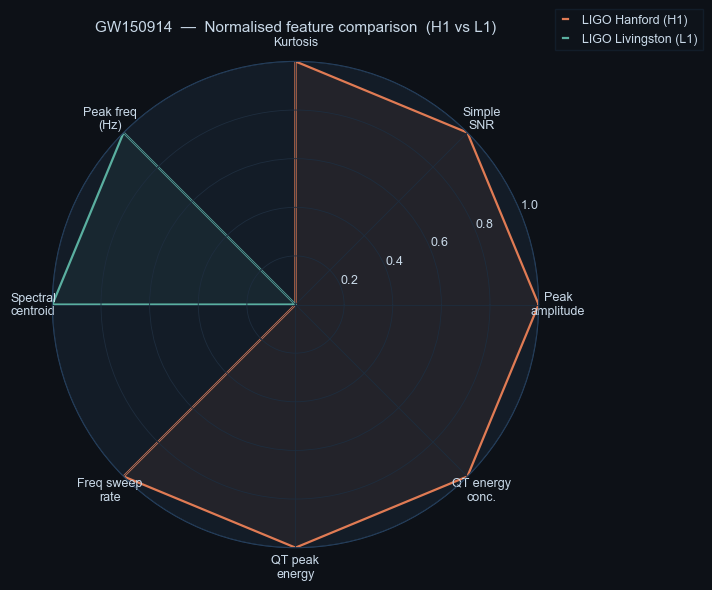

Figure saved → data\visualisations\GW150914_feature_radar.png


In [11]:
# Subset of features for the radar — must all be positive and finite
radar_features = [
    "peak_amplitude",
    "simple_snr",
    "kurtosis",
    "peak_frequency_hz",
    "spectral_centroid_hz",
    "freq_sweep_rate_hz_s",
    "qt_peak_energy",
    "qt_energy_concentration",
]

radar_labels = [
    "Peak\namplitude", "Simple\nSNR",    "Kurtosis",
    "Peak freq\n(Hz)",  "Spectral\ncentroid",
    "Freq sweep\nrate", "QT peak\nenergy", "QT energy\nconc.",
]

# Collect and normalise
values  = {det: np.array([abs(all_features[det].get(f, 0)) for f in radar_features],
                          dtype=float)
           for det in EVENT.DETECTORS}
stacked = np.stack(list(values.values()))
mins    = stacked.min(axis=0)
maxs    = stacked.max(axis=0)
rng     = np.where(maxs - mins > 0, maxs - mins, 1.0)
normed  = {det: (values[det] - mins) / rng for det in EVENT.DETECTORS}

N       = len(radar_features)
angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Polar axes do not inherit facecolor from rcParams cleanly — set explicitly
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_facecolor(SPACE_AXES)
fig.patch.set_facecolor(SPACE_BG)

for det in EVENT.DETECTORS:
    colour = WA_COLOURS.get(det, "#7eb8e0")
    label  = EVENT.DETECTOR_LABELS.get(det, det)
    vals   = normed[det].tolist() + normed[det][:1].tolist()
    ax.plot(angles, vals,  color=colour, lw=1.6, label=label)
    ax.fill(angles, vals,  color=colour, alpha=0.08)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels,
                  fontsize=9, color=SPACE_TEXT)
ax.set_ylim(0, 1)
ax.tick_params(colors=SPACE_TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor(SPACE_BORDER)
ax.grid(color=SPACE_GRID, linewidth=0.6)

ax.set_title(
    f"{EVENT.NAME}  —  Normalised feature comparison  (H1 vs L1)",
    fontsize=11, pad=22, color=SPACE_TEXT
)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12),
          fontsize=9, framealpha=0.2)

fig.savefig(PATHS.viz_output(EVENT.NAME, "feature_radar"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'feature_radar')}")

<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 100%); padding: 28px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-top: 16px;">

<h2 style="color: #e8f4fd; font-weight: 300; margin: 0 0 18px 0; font-size: 1.4em;">Summary &amp; Next Steps</h2>

<p style="color: #a0c4de; margin: 0 0 16px 0;"><strong style="color: #e8f4fd;">What this notebook extracted:</strong></p>

<ul style="color: #c8dce8; margin: 0 0 20px 0; padding-left: 20px; line-height: 1.8;">
<li><strong style="color: #e8f4fd;">6 time-domain features</strong> — peak amplitude, RMS, simple SNR, kurtosis, skewness</li>
<li><strong style="color: #e8f4fd;">4 frequency-domain features</strong> — peak frequency, spectral centroid, bandwidth, entropy</li>
<li><strong style="color: #e8f4fd;">4 chirp physics features</strong> — inspiral frequencies, sweep rate, chirp mass estimate using <code style="background: rgba(78,158,202,0.75); padding: 1px 5px; border-radius: 3px;">PHYSICS.*</code> constants from config.py</li>
<li><strong style="color: #e8f4fd;">4 Q-transform features</strong> — peak energy, time and frequency of peak, energy concentration</li>
<li>Radar chart comparing H1 and L1 feature profiles — both detectors tell a consistent story</li>
</ul>

<p style="color: #a0c4de; margin: 0 0 10px 0;"><strong style="color: #e8f4fd;">Outputs written:</strong></p>
<pre style="background: rgba(78,158,202,0.08); border: 1px solid rgba(78,158,202,0.2); border-radius: 6px; padding: 12px 16px; color: #7eb8e0; font-size: 0.9em; margin: 0 0 20px 0;">
data/features/
├── GW150914_features.json      ← full feature dict, human-readable
└── GW150914_features.csv       ← feature matrix, one row per detector

data/visualisations/
├── GW150914_hilbert_envelope_freq.png
└── GW150914_feature_radar.png
</pre>

<p style="color: #a0c4de; margin: 0 0 6px 0;"><strong style="color: #e8f4fd;">Next — <code style="background: rgba(78,158,202,0.15); padding: 2px 6px; border-radius: 3px; color: #7eb8e0;">05_modelling.ipynb</code>:</strong></p>
<p style="color: #c8dce8; margin: 0;">Load the feature matrix, build a matched filter to compute the proper SNR time series, compare it with the simple RMS estimate from this notebook, and explore how the extracted features relate to the known physical parameters of GW150914.</p>

</div>